# Representational Geometry Meets Superposition

Connecting our toy autoencoder phase diagram to neuroscience representational geometry.

## Motivation

jake_mendel's ["SAE feature geometry is outside the superposition hypothesis"](https://www.alignmentforum.org/posts/MFBTjb2qf3ziWmzz6/sae-feature-geometry-is-outside-the-superposition-hypothesis) makes a key point: the superposition hypothesis says cosine similarities between feature vectors are *incidental interference* from packing too many features into too few dimensions. But empirically, these cosine similarities carry *meaningful semantic structure* — similar features cluster, circular features form rings, etc. This is a different claim: geometry encodes functional organization.

This parallels a deep distinction in neuroscience:

### Two levels of description (Kriegeskorte & Diedrichsen 2019)

| Level | What it captures | Neuroscience tool | ML analog |
|-------|-----------------|-------------------|----------|
| **Information content** | *What* is represented (which features, how strongly) | Linear decoding, single-neuron tuning | SAE feature identification |
| **Representational format/geometry** | *How* it's organized (distances, topology, manifold structure) | RSA / Representational Dissimilarity Matrices | Feature cosine similarities, polytope geometry |

SAEs and the superposition hypothesis focus on Level 1. The "geometry is outside superposition" critique says Level 2 exists and matters. Neuroscience figured this out years ago.

### Key references

1. **Kriegeskorte 2008** — Representational Similarity Analysis (RSA): compare neural codes via pairwise dissimilarity matrices, abstracting away from neuron identity
2. **Kriegeskorte & Diedrichsen 2019** — "Peeling the Onion": representational geometry captures both content and format of population codes
3. **Chung & Abbott 2021** — Neural population geometry: manifold capacity, dimensionality, and radius determine linear separability
4. **Elhage et al. 2022** — Toy Models of Superposition: features organize into polytopes (digons, triangles, pentagons, tetrahedra)
5. **Ivanov et al. 2026** — Spectral Superposition: frame operator F=WW^T classifies feature geometries; capacity saturation forces spectral localization into tight frames
6. **jake_mendel 2024** — SAE feature geometry is outside superposition: cosine similarities are semantically meaningful, not just interference
7. **Park et al. 2025** — "Geometry of Concepts": SAE features show structure at three scales — atomic (parallelogram crystals), intermediate (modular lobes), global (power-law eigenvalues)

### What we'll do

Apply neuroscience representational geometry tools to our toy autoencoders:
1. Compute RDMs (Representational Dissimilarity Matrices) of learned feature vectors
2. Measure manifold geometry: dimensionality, radius, capacity (Chung & Abbott)
3. Compare the frame operator spectrum (Ivanov et al.) across our phase diagram
4. Test whether feature geometry is "incidental" (superposition) vs "meaningful" (representational geometry)

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import squareform
from tqdm import tqdm
import pandas as pd
from core import (
    Autoencoder, train_autoencoder, generate_sparse_data, 
    measure_encoding_linearity, compute_feature_geometry, device
)

print(f"Device: {device}")

Device: cpu


## Part 1: Representational Dissimilarity Matrices (RDMs)

The core tool from Kriegeskorte (2008). For a set of feature vectors $\{w_i\}$ in the bottleneck, compute the pairwise dissimilarity matrix:

$$D_{ij} = 1 - \cos(w_i, w_j)$$

This captures the *format* of the representation — how features relate to each other geometrically — independent of which specific neurons encode them.

In the superposition hypothesis, these distances are *noise* (incidental interference from packing). In representational geometry, they're *signal* (encoding functional relationships).

In [2]:
def get_encoder_weight_matrix(model):
    """Extract the effective encoder weight matrix W (m × n).
    For l=1 tied weights, this is just the encoder weight.
    For deeper models, we use the Jacobian at a representative point.
    """
    if model.tied_weights:
        return model.encoder.weight.detach()  # (m, n)
    elif model.l == 1:
        # Untied but still single layer
        for name, param in model.encoder.named_parameters():
            if 'weight' in name:
                return param.detach()
    else:
        # Deep encoder: use Jacobian at a representative input
        model.eval()
        # Average Jacobian over several inputs for stability
        x_data = generate_sparse_data(50, model.n, S=0.5)
        jacs = []
        for i in range(50):
            xi = x_data[i:i+1].clone().requires_grad_(True)
            zi = model.encode(xi)
            jac = torch.zeros(model.m, model.n, device=device)
            for j in range(model.m):
                if xi.grad is not None:
                    xi.grad.zero_()
                zi[0, j].backward(retain_graph=True)
                jac[j] = xi.grad[0]
            jacs.append(jac)
        return torch.stack(jacs).mean(dim=0)  # (m, n)


def compute_rdm(W, metric='cosine'):
    """Compute Representational Dissimilarity Matrix for feature vectors.
    
    W: (m, n) weight matrix — columns are feature vectors in bottleneck space.
    Returns (n, n) dissimilarity matrix.
    """
    # Feature vectors are columns of W: w_i = W[:, i] (m-dimensional)
    features = W.T  # (n, m) — each row is a feature's representation
    
    if metric == 'cosine':
        norms = features.norm(dim=1, keepdim=True) + 1e-8
        features_normed = features / norms
        cos_sim = features_normed @ features_normed.T
        rdm = (1 - cos_sim).cpu().numpy()
    elif metric == 'euclidean':
        dists = torch.cdist(features, features)
        rdm = dists.cpu().numpy()
    
    return rdm


def compute_frame_operator(W):
    """Compute frame operator F = WW^T and its spectrum.
    
    From Ivanov et al. (2026) "Spectral Superposition":
    F is invariant to feature permutations and reveals
    how features collectively organize in activation space.
    
    W: (m, n) — rows are activation dims, columns are features
    F = WW^T: (m, m)
    """
    F = W @ W.T  # (m, m)
    eigenvalues = torch.linalg.eigvalsh(F)  # ascending order
    eigenvalues = eigenvalues.flip(0)  # descending
    return F.cpu().numpy(), eigenvalues.cpu().numpy()


def compute_gram_matrix(W):
    """Compute Gram matrix M = W^T W and its spectrum.
    
    M_{ij} = <w_i, w_j> gives pairwise feature interactions.
    W: (m, n)
    M = W^T W: (n, n)
    """
    M = W.T @ W  # (n, n)
    eigenvalues = torch.linalg.eigvalsh(M)
    eigenvalues = eigenvalues.flip(0)
    return M.cpu().numpy(), eigenvalues.cpu().numpy()


def compute_manifold_geometry(W):
    """Measure manifold geometry metrics from Chung & Abbott (2021).
    
    For a set of feature vectors, compute:
    - Effective dimensionality (participation ratio of singular values)
    - Mean radius (mean norm of feature vectors)
    - Center norm (norm of mean feature vector)
    - Capacity proxy: how well features can be linearly separated
    """
    features = W.T.cpu().numpy()  # (n, m) — feature vectors
    n, m = features.shape
    
    # Center
    center = features.mean(axis=0)
    center_norm = np.linalg.norm(center)
    
    # Centered features
    centered = features - center
    
    # SVD of centered features
    U, s, Vt = np.linalg.svd(centered, full_matrices=False)
    
    # Effective dimensionality (participation ratio)
    s2 = s ** 2
    if s2.sum() > 0:
        eff_dim = (s2.sum()) ** 2 / (s2 ** 2).sum()
    else:
        eff_dim = 0
    
    # Mean radius
    radii = np.linalg.norm(centered, axis=1)
    mean_radius = radii.mean()
    
    # Norms
    norms = np.linalg.norm(features, axis=1)
    
    # Capacity proxy: fraction of random dichotomies that are linearly separable
    # (simplified version of Chung & Abbott's manifold capacity)
    n_dichotomies = min(200, 2**n)
    n_separable = 0
    for _ in range(n_dichotomies):
        labels = np.random.choice([-1, 1], size=n)
        # Check linear separability via least-squares classification
        try:
            w_cls, _, _, _ = np.linalg.lstsq(features, labels, rcond=None)
            preds = np.sign(features @ w_cls)
            if np.all(preds == labels):
                n_separable += 1
        except:
            pass
    capacity = n_separable / n_dichotomies
    
    return {
        'eff_dim': eff_dim,
        'mean_radius': mean_radius,
        'center_norm': center_norm,
        'radius_std': radii.std(),
        'norms': norms,
        'capacity': capacity,
        'singular_values': s,
    }


print("Geometry tools defined.")

Geometry tools defined.


## Part 2: Train autoencoders across the phase diagram

Sweep over (n, m, l) and compute representational geometry metrics for each.

In [3]:
# Sweep parameters
n_values = [8, 16, 32]
ratios = [0.25, 0.5, 0.75, 1.0]  # m/n
depths = [1, 2, 3]
S = 0.95
n_steps = 8000
n_seeds = 3

all_results = []

total = len(n_values) * len(ratios) * len(depths) * n_seeds
pbar = tqdm(total=total, desc="Geometry sweep")

for n in n_values:
    for ratio in ratios:
        m = max(2, int(n * ratio))  # need at least 2 bottleneck dims for geometry
        for l in depths:
            for seed in range(n_seeds):
                torch.manual_seed(seed)
                np.random.seed(seed)
                
                model = Autoencoder(n, m, l=l, tied_weights=(l==1)).to(device)
                losses = train_autoencoder(model, n_steps=n_steps, S=S, verbose=False)
                
                # Get weight matrix and compute geometry
                W = get_encoder_weight_matrix(model)
                rdm = compute_rdm(W)
                F, F_eigs = compute_frame_operator(W)
                M, M_eigs = compute_gram_matrix(W)
                manifold = compute_manifold_geometry(W)
                linearity = measure_encoding_linearity(model, S=S)
                
                # RDM statistics
                rdm_upper = rdm[np.triu_indices_from(rdm, k=1)]
                
                # Frame operator statistics
                F_eigs_pos = F_eigs[F_eigs > 1e-8]
                if len(F_eigs_pos) > 0:
                    F_eigs_norm = F_eigs_pos / F_eigs_pos.sum()
                    F_eff_rank = np.exp(-np.sum(F_eigs_norm * np.log(F_eigs_norm + 1e-10)))
                    F_top1_frac = F_eigs_pos[0] / F_eigs_pos.sum()
                else:
                    F_eff_rank = 0
                    F_top1_frac = 0
                
                result = {
                    'n': n, 'm': m, 'l': l, 'ratio': ratio, 'seed': seed,
                    'final_loss': np.mean(losses[-200:]),
                    'nonlinear_gain': linearity['nonlinear_gain'],
                    # RDM statistics
                    'rdm_mean': rdm_upper.mean(),
                    'rdm_std': rdm_upper.std(),
                    'rdm_min': rdm_upper.min(),
                    'rdm_max': rdm_upper.max(),
                    # Frame operator
                    'F_eff_rank': F_eff_rank,
                    'F_top1_frac': F_top1_frac,
                    # Manifold geometry (Chung & Abbott)
                    'eff_dim': manifold['eff_dim'],
                    'mean_radius': manifold['mean_radius'],
                    'center_norm': manifold['center_norm'],
                    'capacity': manifold['capacity'],
                    # Derived
                    'norm_cv': manifold['norms'].std() / (manifold['norms'].mean() + 1e-8),
                }
                all_results.append(result)
                
                pbar.update(1)
                pbar.set_postfix({'n': n, 'm': m, 'l': l, 
                                  'nl_gain': f"{linearity['nonlinear_gain']:.3f}"})

pbar.close()
df = pd.DataFrame(all_results)
print(f"Collected {len(df)} results")
df.head()

Geometry sweep:   0%|          | 0/108 [00:00<?, ?it/s]

Geometry sweep:   1%|          | 1/108 [00:01<03:25,  1.92s/it]

Geometry sweep:   1%|          | 1/108 [00:01<03:25,  1.92s/it, n=8, m=2, l=1, nl_gain=0.000]

Geometry sweep:   2%|▏         | 2/108 [00:03<02:48,  1.59s/it, n=8, m=2, l=1, nl_gain=0.000]

Geometry sweep:   2%|▏         | 2/108 [00:03<02:48,  1.59s/it, n=8, m=2, l=1, nl_gain=-0.000]

...

Geometry sweep: 100%|██████████| 108/108 [05:23<00:00,  6.42s/it, n=32, m=32, l=3, nl_gain=0.057]

Geometry sweep: 100%|██████████| 108/108 [05:23<00:00,  6.42s/it, n=32, m=32, l=3, nl_gain=0.027]

Geometry sweep: 100%|██████████| 108/108 [05:23<00:00,  3.00s/it, n=32, m=32, l=3, nl_gain=0.027]

Collected 108 results


,n,m,l,ratio,seed,final_loss,nonlinear_gain,rdm_mean,rdm_std,rdm_min,rdm_max,F_eff_rank,F_top1_frac,eff_dim,mean_radius,center_norm,capacity,norm_cv
0,8,2,1,0.25,0,0.007130,7.261039e-08,1.039777,0.663514,2.384186e-07,1.845307,1.999981,0.502149,1.999991,0.779030,0.070528,0.045,0.487801
1,8,2,1,0.25,1,0.007048,-1.305273e-07,1.097196,0.649882,1.202226e-04,1.827667,1.999993,0.501303,1.999970,0.792452,0.048740,0.060,0.481605
2,8,2,1,0.25,2,0.007076,-7.146906e-08,1.107343,0.681124,2.199411e-05,1.843574,1.999929,0.504205,1.999858,0.789517,0.035428,0.035,0.498034
3,8,2,2,0.25,0,0.004993,3.930431e-02,1.096711,0.814876,1.559836e-02,1.997404,1.154742,0.967338,1.079261,2.466949,1.418311,0.015,1.545768
4,8,2,2,0.25,1,0.006679,2.230048e-02,1.136168,0.704975,1.637816e-03,1.997809,1.730602,0.762253,1.583152,0.919946,0.184520,0.025,0.970326


## Part 3: RDM analysis — is feature geometry meaningful or incidental?

The jake_mendel critique: if superposition is the whole story, the RDM should look like random packing. If representational geometry matters, the RDM should show structure (clustering, ordering) that reflects feature relationships.

**Test**: Compare the RDM of trained models to RDMs from random weight matrices matched in (n, m). If trained RDMs are more structured (lower entropy, more clustering), then geometry goes beyond superposition.

n=8, m=4, l=1:
  Trained  — entropy: 0.592, CV: 0.306
  Random   — entropy: 0.954, CV: 0.424



n=16, m=8, l=1:
  Trained  — entropy: 0.353, CV: 0.234
  Random   — entropy: 0.942, CV: 0.369



n=16, m=8, l=3:
  Trained  — entropy: 0.890, CV: 0.337
  Random   — entropy: 0.935, CV: 0.328



n=32, m=8, l=3:
  Trained  — entropy: 0.924, CV: 0.373
  Random   — entropy: 0.924, CV: 0.353



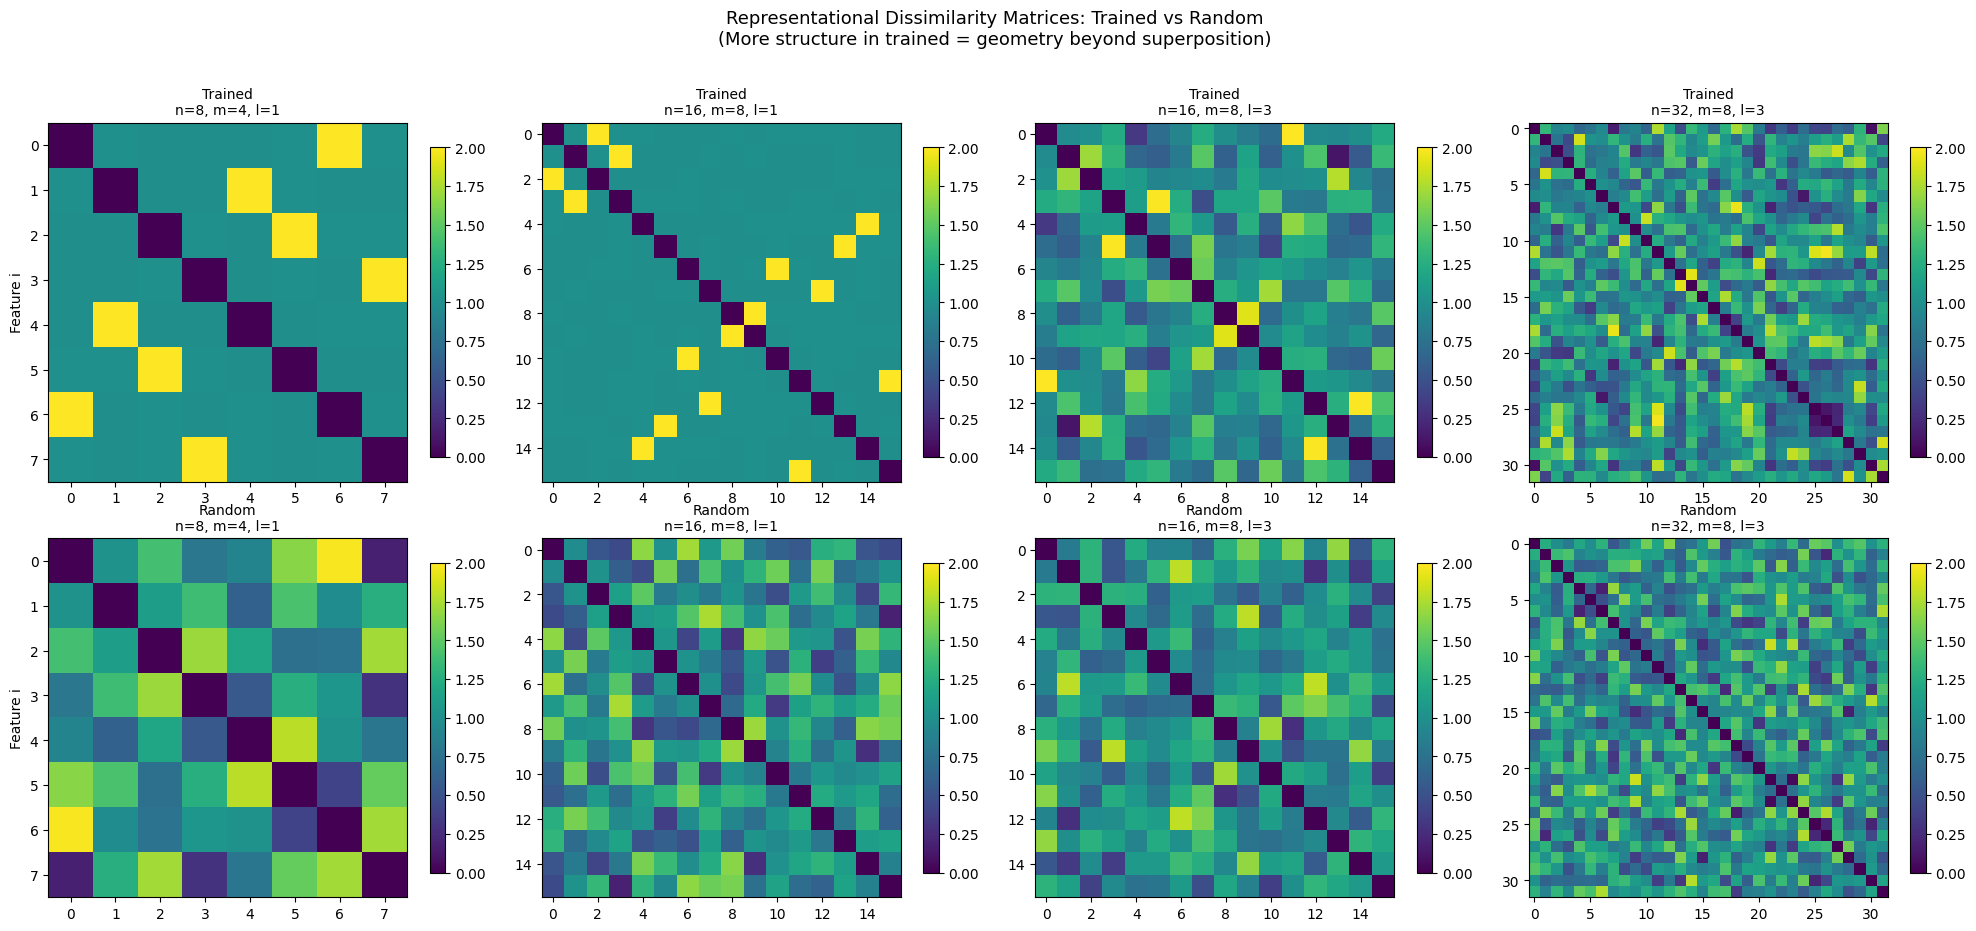

In [4]:
def rdm_structure_score(rdm):
    """Measure how much structure an RDM has beyond uniform packing.
    
    Uses two metrics:
    1. Entropy of the distance distribution (lower = more structured)
    2. Coefficient of variation of distances (higher = more structured)
    """
    upper = rdm[np.triu_indices_from(rdm, k=1)]
    if len(upper) == 0:
        return {'entropy': 0, 'cv': 0}
    
    # Histogram entropy — use counts not density to avoid negative values
    hist, _ = np.histogram(upper, bins=20)
    hist = hist[hist > 0].astype(float)
    hist /= hist.sum()  # normalize to probability
    entropy = -np.sum(hist * np.log(hist)) / np.log(len(hist) + 1e-10)  # normalized [0,1]
    
    # CV
    cv = upper.std() / (upper.mean() + 1e-8)
    
    return {'entropy': entropy, 'cv': cv}


# Compare trained vs random RDMs for several configurations
fig, axes = plt.subplots(2, 4, figsize=(20, 9))

configs = [
    (8, 4, 1, 'n=8, m=4, l=1'),
    (16, 8, 1, 'n=16, m=8, l=1'),
    (16, 8, 3, 'n=16, m=8, l=3'),
    (32, 8, 3, 'n=32, m=8, l=3'),
]

for col_idx, (n, m, l, title) in enumerate(configs):
    torch.manual_seed(0)
    
    # Train model
    model = Autoencoder(n, m, l=l, tied_weights=(l==1)).to(device)
    train_autoencoder(model, n_steps=n_steps, S=S, verbose=False)
    W_trained = get_encoder_weight_matrix(model)
    rdm_trained = compute_rdm(W_trained)
    
    # Random baseline (same dimensions)
    W_random = torch.randn(m, n, device=device)
    rdm_random = compute_rdm(W_random)
    
    # Plot trained RDM
    ax = axes[0, col_idx]
    im = ax.imshow(rdm_trained, cmap='viridis', vmin=0, vmax=2)
    ax.set_title(f'Trained\n{title}', fontsize=10)
    if col_idx == 0:
        ax.set_ylabel('Feature i')
    plt.colorbar(im, ax=ax, shrink=0.8)
    
    # Plot random RDM
    ax = axes[1, col_idx]
    im = ax.imshow(rdm_random, cmap='viridis', vmin=0, vmax=2)
    ax.set_title(f'Random\n{title}', fontsize=10)
    if col_idx == 0:
        ax.set_ylabel('Feature i')
    plt.colorbar(im, ax=ax, shrink=0.8)
    
    # Print structure scores
    s_trained = rdm_structure_score(rdm_trained)
    s_random = rdm_structure_score(rdm_random)
    print(f"{title}:")
    print(f"  Trained  — entropy: {s_trained['entropy']:.3f}, CV: {s_trained['cv']:.3f}")
    print(f"  Random   — entropy: {s_random['entropy']:.3f}, CV: {s_random['cv']:.3f}")
    print()

plt.suptitle('Representational Dissimilarity Matrices: Trained vs Random\n'
             '(More structure in trained = geometry beyond superposition)',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

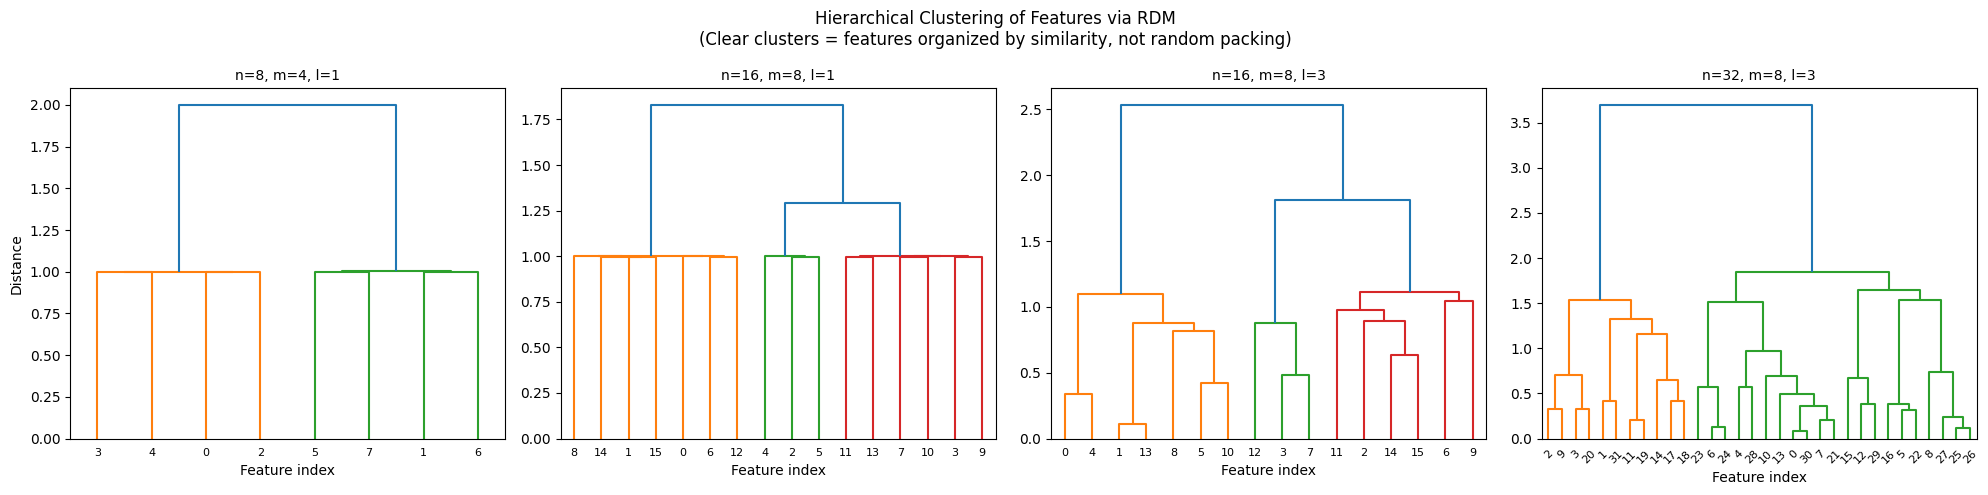

In [5]:
# Hierarchical clustering of features via RDM — does it reveal meaningful groups?
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for col_idx, (n, m, l, title) in enumerate(configs):
    torch.manual_seed(0)
    model = Autoencoder(n, m, l=l, tied_weights=(l==1)).to(device)
    train_autoencoder(model, n_steps=n_steps, S=S, verbose=False)
    W = get_encoder_weight_matrix(model)
    rdm = compute_rdm(W)
    
    # Convert to condensed form for hierarchical clustering
    np.fill_diagonal(rdm, 0)
    rdm_sym = (rdm + rdm.T) / 2  # ensure symmetry
    rdm_clipped = np.clip(rdm_sym, 0, None)  # ensure non-negative
    condensed = squareform(rdm_clipped)
    
    Z = linkage(condensed, method='ward')
    
    ax = axes[col_idx]
    dendrogram(Z, ax=ax, leaf_font_size=8)
    ax.set_title(f'{title}', fontsize=10)
    ax.set_xlabel('Feature index')
    if col_idx == 0:
        ax.set_ylabel('Distance')

plt.suptitle('Hierarchical Clustering of Features via RDM\n'
             '(Clear clusters = features organized by similarity, not random packing)',
             fontsize=12)
plt.tight_layout()
plt.show()

## Part 4: Frame operator spectrum (Spectral Superposition)

Ivanov et al. show that the frame operator $F = WW^T$ reveals how features collectively organize. At capacity saturation, features spectrally localize — each feature collapses onto a single eigenspace of $F$.

**Prediction**: As $n/m$ increases (more superposition), the frame operator spectrum should become more uniform (features spread across eigenspaces). At low $n/m$, features should localize (concentrate in fewer eigenspaces).

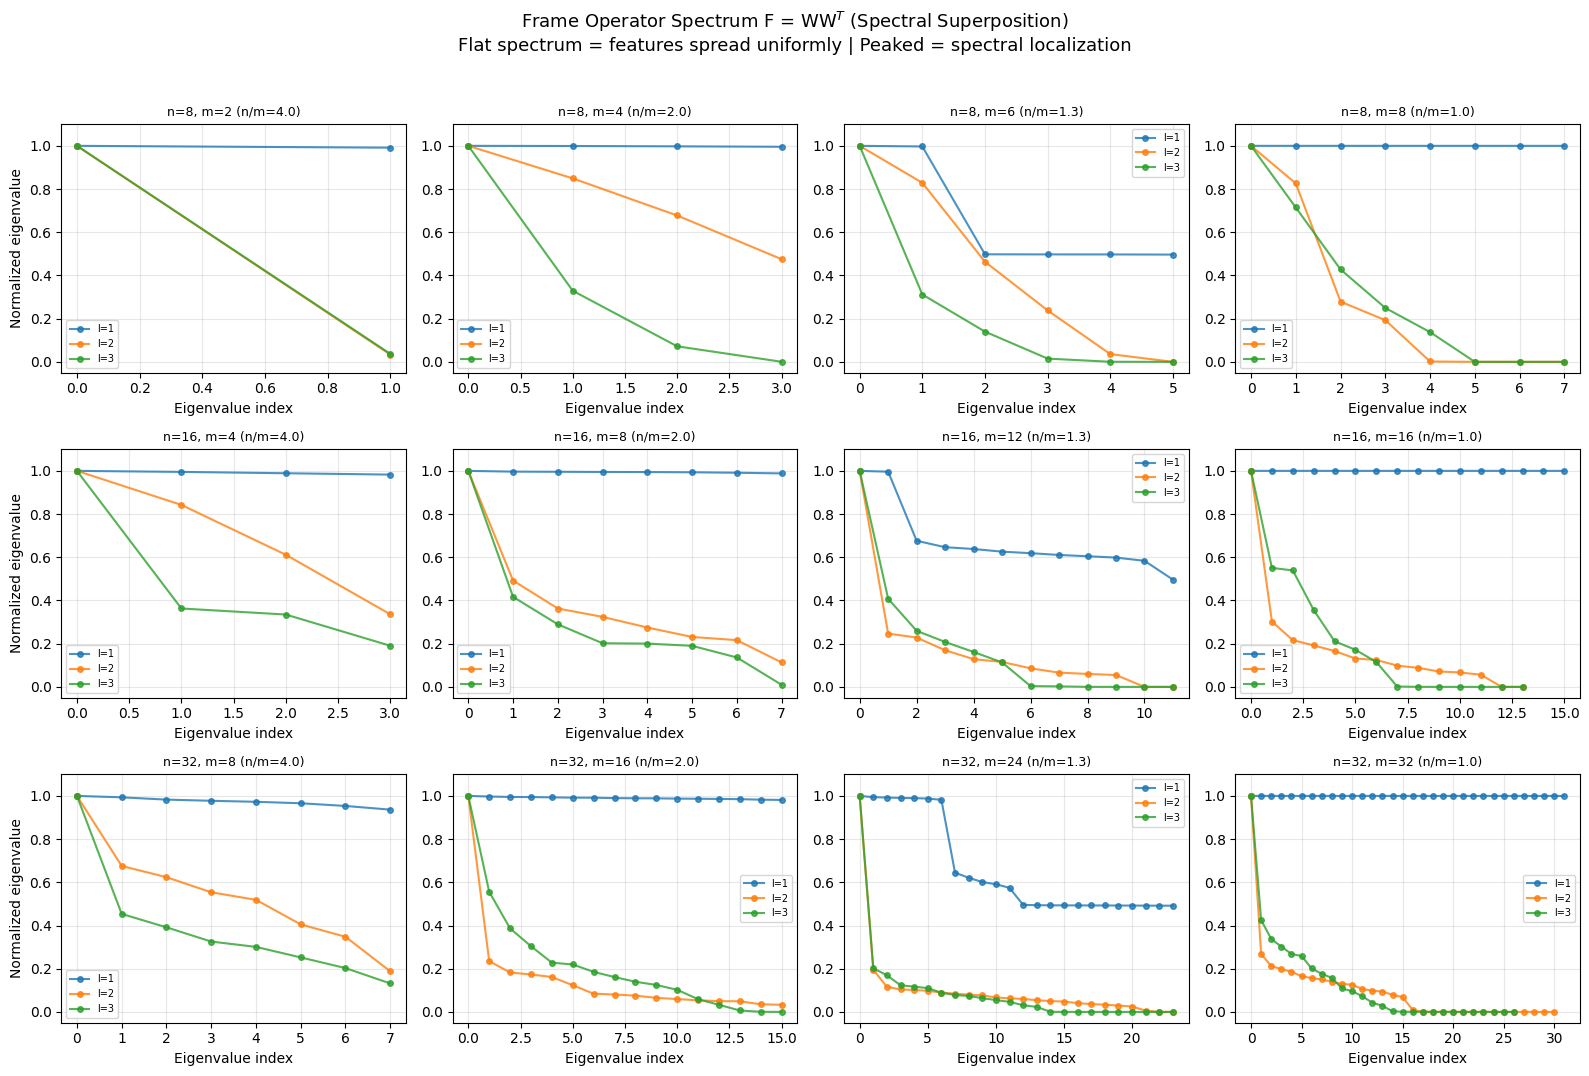

In [6]:
# Frame operator spectrum across the phase diagram
fig, axes = plt.subplots(len(n_values), len(ratios), figsize=(4*len(ratios), 3.5*len(n_values)))

for row_idx, n in enumerate(n_values):
    for col_idx, ratio in enumerate(ratios):
        ax = axes[row_idx, col_idx]
        m = max(2, int(n * ratio))
        
        for l in depths:
            torch.manual_seed(0)
            model = Autoencoder(n, m, l=l, tied_weights=(l==1)).to(device)
            train_autoencoder(model, n_steps=n_steps, S=S, verbose=False)
            W = get_encoder_weight_matrix(model)
            _, F_eigs = compute_frame_operator(W)
            
            F_eigs_pos = F_eigs[F_eigs > 1e-8]
            if len(F_eigs_pos) > 0:
                F_eigs_norm = F_eigs_pos / F_eigs_pos.max()
                ax.plot(range(len(F_eigs_norm)), F_eigs_norm, 
                       marker='o', markersize=4, label=f'l={l}', alpha=0.8)
        
        ax.set_title(f'n={n}, m={m} (n/m={n/m:.1f})', fontsize=9)
        ax.set_xlabel('Eigenvalue index')
        if col_idx == 0:
            ax.set_ylabel('Normalized eigenvalue')
        ax.legend(fontsize=7)
        ax.grid(True, alpha=0.3)
        ax.set_ylim(-0.05, 1.1)

plt.suptitle('Frame Operator Spectrum F = WW$^T$ (Spectral Superposition)\n'
             'Flat spectrum = features spread uniformly | Peaked = spectral localization',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

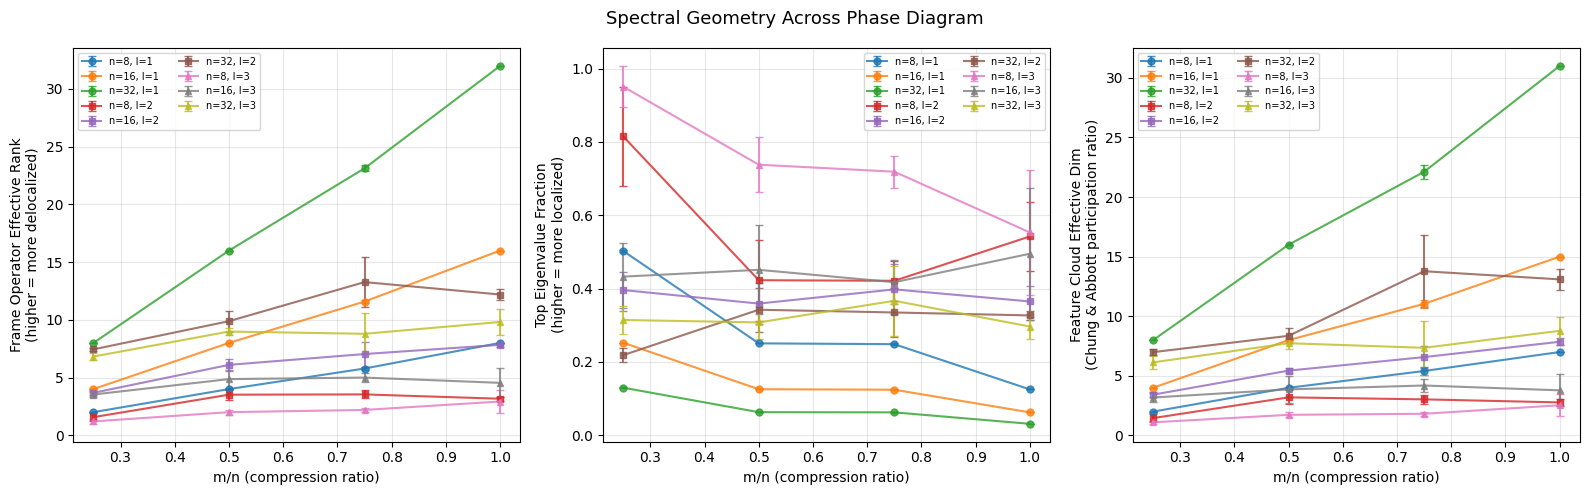

In [7]:
# Spectral localization vs compression: summary plot
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

metrics = [
    ('F_eff_rank', 'Frame Operator Effective Rank\n(higher = more delocalized)'),
    ('F_top1_frac', 'Top Eigenvalue Fraction\n(higher = more localized)'),
    ('eff_dim', 'Feature Cloud Effective Dim\n(Chung & Abbott participation ratio)'),
]

for ax_idx, (metric, ylabel) in enumerate(metrics):
    ax = axes[ax_idx]
    
    for l in depths:
        for n in n_values:
            mask = (df['l'] == l) & (df['n'] == n)
            sub = df[mask].groupby('ratio')[metric].agg(['mean', 'std']).reset_index()
            
            ax.errorbar(sub['ratio'], sub['mean'], yerr=sub['std'],
                       marker='os^'[depths.index(l)], 
                       label=f'n={n}, l={l}',
                       capsize=3, markersize=5, alpha=0.8)
    
    ax.set_xlabel('m/n (compression ratio)')
    ax.set_ylabel(ylabel)
    ax.legend(fontsize=7, ncol=2)
    ax.grid(True, alpha=0.3)

plt.suptitle('Spectral Geometry Across Phase Diagram', fontsize=13)
plt.tight_layout()
plt.show()

## Part 5: Manifold geometry (Chung & Abbott)

In neuroscience, the key insight is that layer-by-layer processing transforms object manifolds to increase their linear separability. Three quantities matter:
- **Dimensionality**: Lower-D manifolds are easier to separate
- **Radius**: Smaller manifolds are easier to separate  
- **Center norm**: How far the manifold center is from origin

Applied to our autoencoders: as we compress (reduce $m/n$), how does the feature manifold geometry change? Does depth affect this differently?

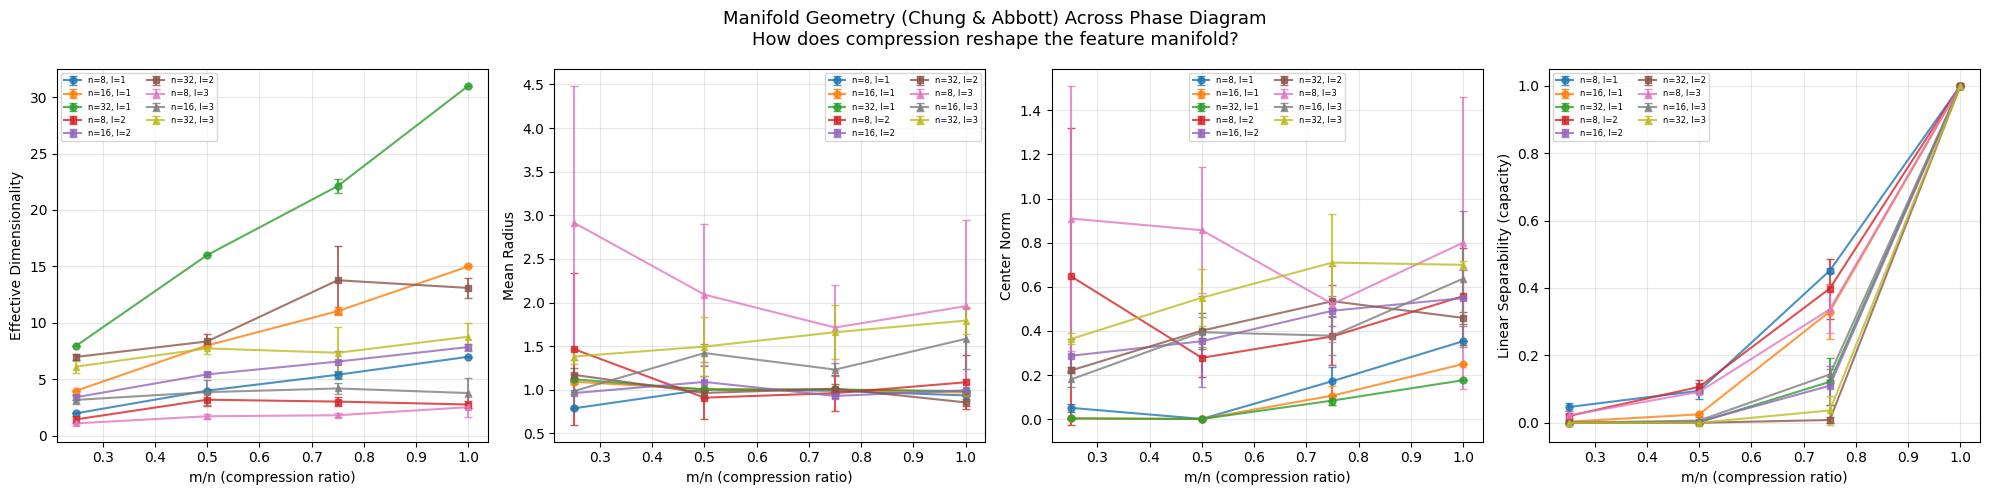

In [8]:
# Manifold geometry across phase diagram
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

manifold_metrics = [
    ('eff_dim', 'Effective Dimensionality'),
    ('mean_radius', 'Mean Radius'),
    ('center_norm', 'Center Norm'),
    ('capacity', 'Linear Separability (capacity)'),
]

for ax_idx, (metric, ylabel) in enumerate(manifold_metrics):
    ax = axes[ax_idx]
    
    for l in depths:
        for n in n_values:
            mask = (df['l'] == l) & (df['n'] == n)
            sub = df[mask].groupby('ratio')[metric].agg(['mean', 'std']).reset_index()
            
            ax.errorbar(sub['ratio'], sub['mean'], yerr=sub['std'],
                       marker='os^'[depths.index(l)],
                       label=f'n={n}, l={l}',
                       capsize=3, markersize=5, alpha=0.8)
    
    ax.set_xlabel('m/n (compression ratio)')
    ax.set_ylabel(ylabel)
    ax.legend(fontsize=6, ncol=2)
    ax.grid(True, alpha=0.3)

plt.suptitle('Manifold Geometry (Chung & Abbott) Across Phase Diagram\n'
             'How does compression reshape the feature manifold?',
             fontsize=13)
plt.tight_layout()
plt.show()

## Part 6: The superposition test — incidental vs meaningful geometry

**Key experiment**: If feature geometry is *incidental* (just packing), then:
1. The RDM structure score should match random baselines
2. Feature norm variance (CV) should be low (uniform importance in superposition)
3. The Gram matrix eigenspectrum should match random matrix theory predictions

If geometry is *meaningful* (representational geometry):
1. Trained RDMs should have more structure than random
2. Feature norms should vary (some features matter more)
3. Gram eigenspectrum should deviate from random matrix predictions

We test this across the phase diagram.

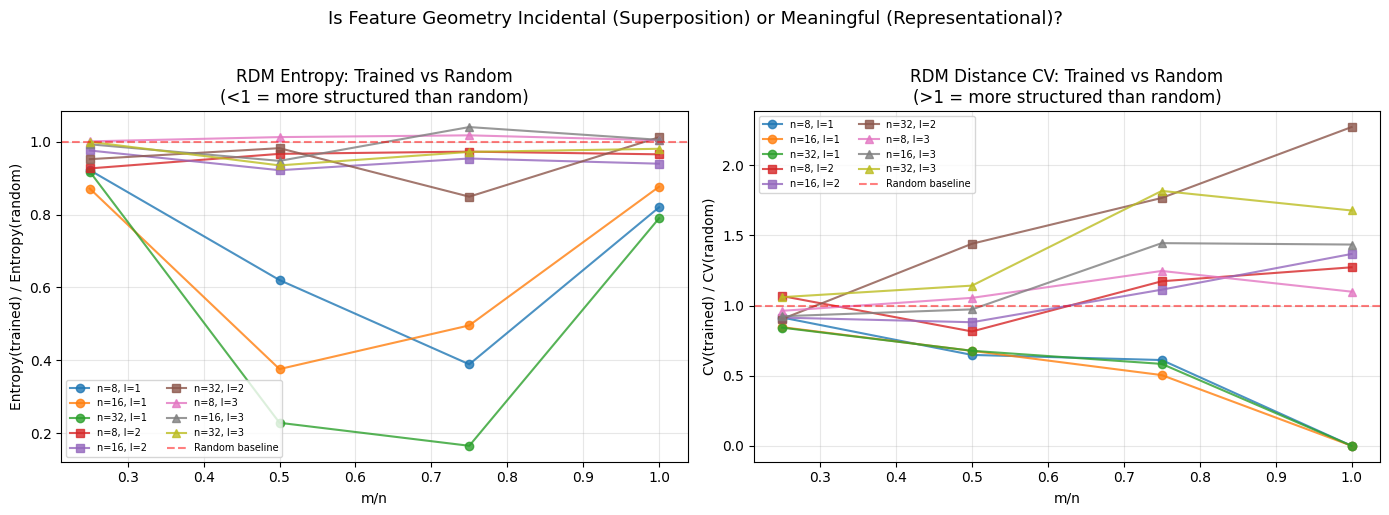

In [9]:
# Compare trained vs random geometry at each point in phase diagram
comparison_results = []

for n in n_values:
    for ratio in ratios:
        m = max(2, int(n * ratio))
        for l in depths:
            # Trained model
            torch.manual_seed(0)
            model = Autoencoder(n, m, l=l, tied_weights=(l==1)).to(device)
            train_autoencoder(model, n_steps=n_steps, S=S, verbose=False)
            W_trained = get_encoder_weight_matrix(model)
            rdm_trained = compute_rdm(W_trained)
            s_trained = rdm_structure_score(rdm_trained)
            _, F_eigs_trained = compute_frame_operator(W_trained)
            
            # Random baselines (average over several)
            random_entropies = []
            random_cvs = []
            for rs in range(10):
                W_rand = torch.randn(m, n, device=device)
                rdm_rand = compute_rdm(W_rand)
                s_rand = rdm_structure_score(rdm_rand)
                random_entropies.append(s_rand['entropy'])
                random_cvs.append(s_rand['cv'])
            
            comparison_results.append({
                'n': n, 'm': m, 'l': l, 'ratio': ratio,
                'trained_entropy': s_trained['entropy'],
                'trained_cv': s_trained['cv'],
                'random_entropy_mean': np.mean(random_entropies),
                'random_cv_mean': np.mean(random_cvs),
                'entropy_ratio': s_trained['entropy'] / (np.mean(random_entropies) + 1e-8),
                'cv_ratio': s_trained['cv'] / (np.mean(random_cvs) + 1e-8),
            })

df_comp = pd.DataFrame(comparison_results)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Entropy ratio
ax = axes[0]
for l in depths:
    for n in n_values:
        mask = (df_comp['l'] == l) & (df_comp['n'] == n)
        sub = df_comp[mask]
        ax.plot(sub['ratio'], sub['entropy_ratio'], 
               marker='os^'[depths.index(l)], label=f'n={n}, l={l}', alpha=0.8)

ax.axhline(y=1.0, color='red', linestyle='--', alpha=0.5, label='Random baseline')
ax.set_xlabel('m/n')
ax.set_ylabel('Entropy(trained) / Entropy(random)')
ax.set_title('RDM Entropy: Trained vs Random\n(<1 = more structured than random)')
ax.legend(fontsize=7, ncol=2)
ax.grid(True, alpha=0.3)

# CV ratio
ax = axes[1]
for l in depths:
    for n in n_values:
        mask = (df_comp['l'] == l) & (df_comp['n'] == n)
        sub = df_comp[mask]
        ax.plot(sub['ratio'], sub['cv_ratio'],
               marker='os^'[depths.index(l)], label=f'n={n}, l={l}', alpha=0.8)

ax.axhline(y=1.0, color='red', linestyle='--', alpha=0.5, label='Random baseline')
ax.set_xlabel('m/n')
ax.set_ylabel('CV(trained) / CV(random)')
ax.set_title('RDM Distance CV: Trained vs Random\n(>1 = more structured than random)')
ax.legend(fontsize=7, ncol=2)
ax.grid(True, alpha=0.3)

plt.suptitle('Is Feature Geometry Incidental (Superposition) or Meaningful (Representational)?',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## Part 7: Gram matrix eigenspectra — superposition polytopes

Elhage et al. found that superposition organizes features into polytopes (simplices, polygons). Ivanov et al. showed these are tight frames classified by the Gram matrix eigenstructure.

Here we visualize the Gram eigenspectrum and check for the discrete, structured spectra predicted by spectral superposition theory.

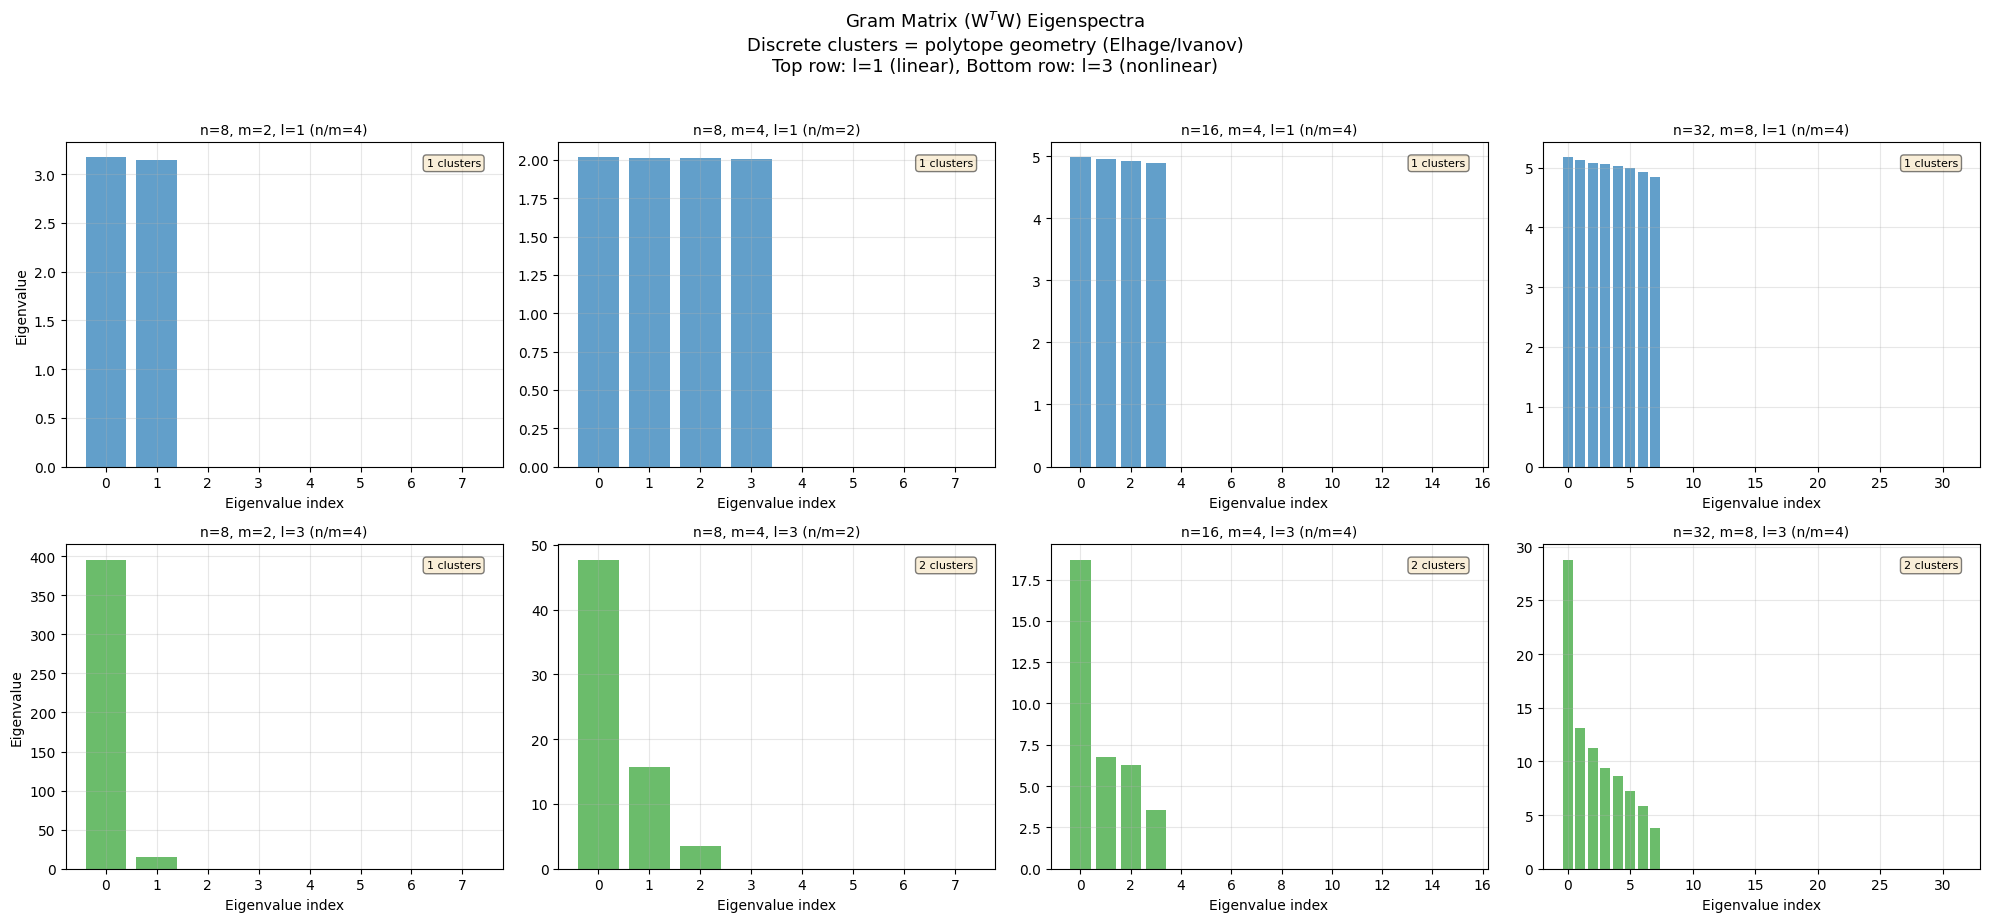

In [10]:
# Gram matrix eigenspectra for representative configs
fig, axes = plt.subplots(2, 4, figsize=(20, 9))

detail_configs = [
    (8, 2, 1), (8, 4, 1), (16, 4, 1), (32, 8, 1),
    (8, 2, 3), (8, 4, 3), (16, 4, 3), (32, 8, 3),
]

for idx, (n, m, l) in enumerate(detail_configs):
    row, col = idx // 4, idx % 4
    ax = axes[row, col]
    
    torch.manual_seed(0)
    model = Autoencoder(n, m, l=l, tied_weights=(l==1)).to(device)
    train_autoencoder(model, n_steps=n_steps, S=S, verbose=False)
    W = get_encoder_weight_matrix(model)
    M, M_eigs = compute_gram_matrix(W)
    
    # Plot eigenspectrum
    ax.bar(range(len(M_eigs)), M_eigs, alpha=0.7, color=f'C{l-1}')
    ax.set_title(f'n={n}, m={m}, l={l} (n/m={n/m:.0f})', fontsize=10)
    ax.set_xlabel('Eigenvalue index')
    if col == 0:
        ax.set_ylabel('Eigenvalue')
    ax.grid(True, alpha=0.3)
    
    # Count distinct eigenvalue clusters
    eigs_sorted = np.sort(M_eigs)[::-1]
    eigs_pos = eigs_sorted[eigs_sorted > 1e-6]
    if len(eigs_pos) > 1:
        # Count clusters via gap analysis
        gaps = np.diff(eigs_pos)
        median_gap = np.median(np.abs(gaps))
        n_clusters = 1 + np.sum(np.abs(gaps) > 3 * median_gap)
        ax.text(0.95, 0.95, f'{n_clusters} clusters', 
               transform=ax.transAxes, ha='right', va='top', fontsize=8,
               bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.suptitle('Gram Matrix (W$^T$W) Eigenspectra\n'
             'Discrete clusters = polytope geometry (Elhage/Ivanov)\n'
             'Top row: l=1 (linear), Bottom row: l=3 (nonlinear)',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## Part 8: Connecting nonlinear gain to representational geometry

The central question: how does the transition from linear to nonlinear encoding relate to representational geometry?

**Hypothesis**: Nonlinear encoding (depth > 1, nonlinear gain > 0) should produce richer representational geometry — more structured RDMs, different manifold properties — because it has more degrees of freedom for organizing features.

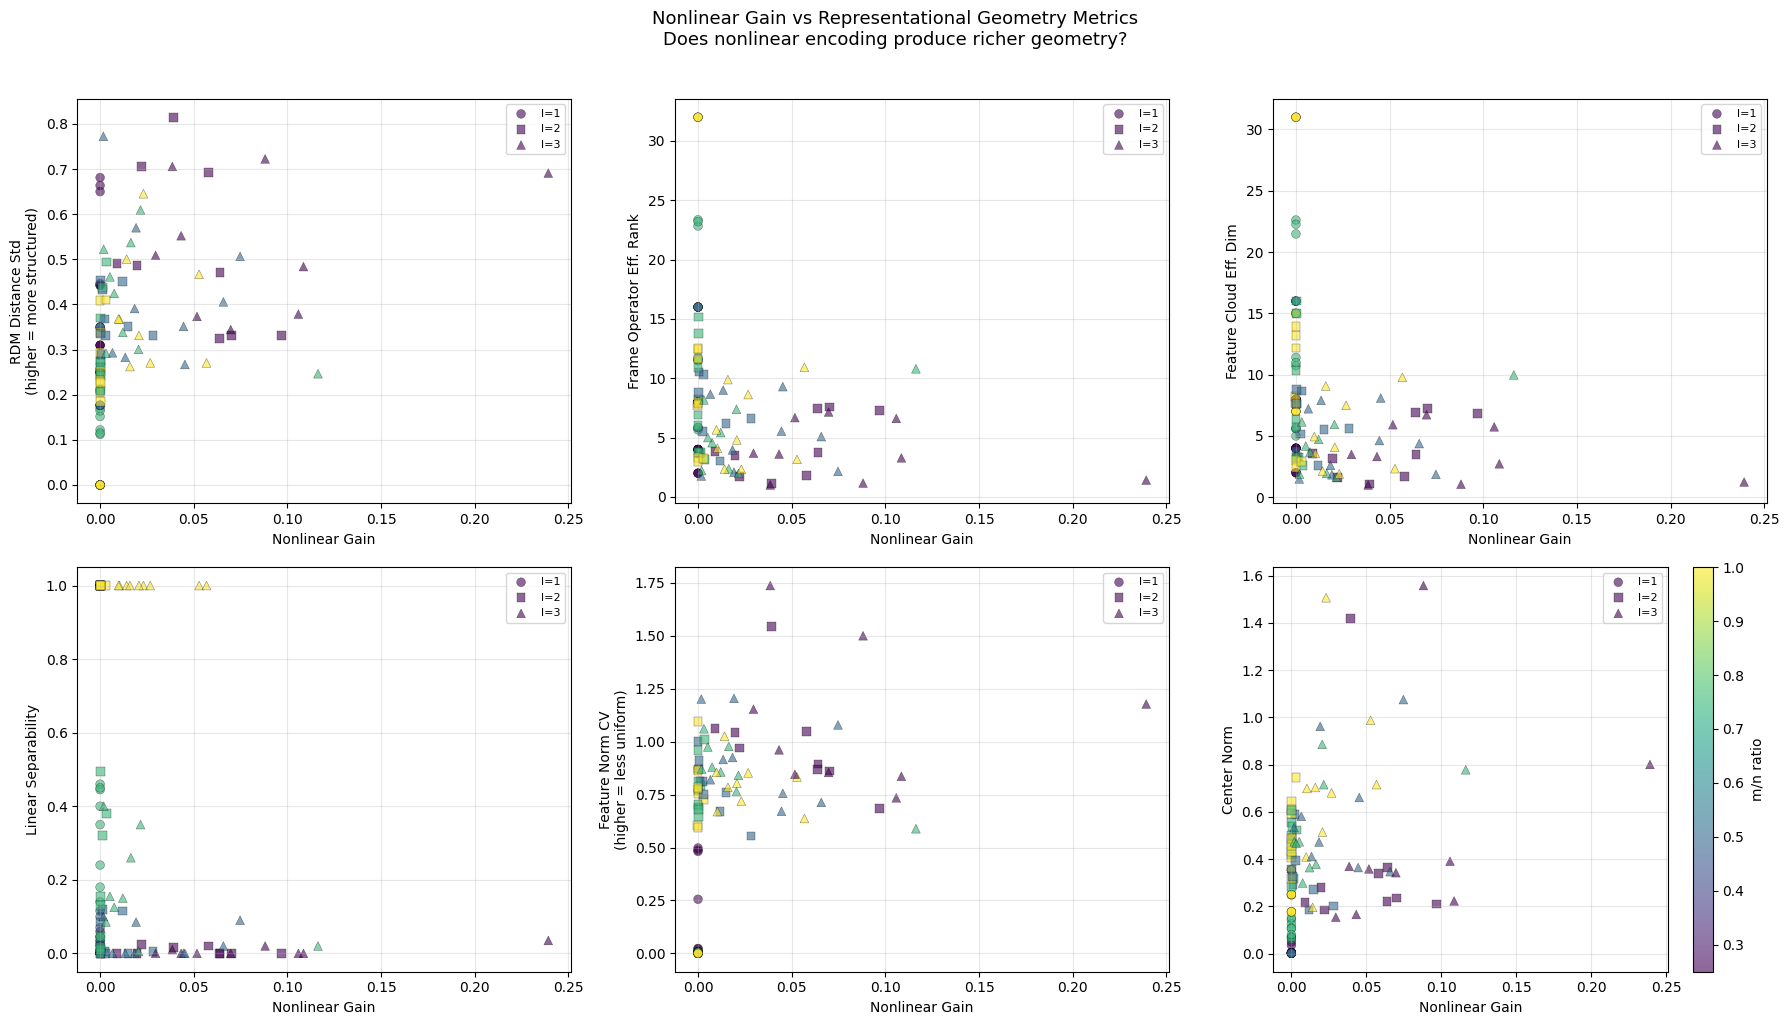

In [11]:
# Scatter: nonlinear gain vs geometry metrics
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

geometry_metrics = [
    ('rdm_std', 'RDM Distance Std\n(higher = more structured)'),
    ('F_eff_rank', 'Frame Operator Eff. Rank'),
    ('eff_dim', 'Feature Cloud Eff. Dim'),
    ('capacity', 'Linear Separability'),
    ('norm_cv', 'Feature Norm CV\n(higher = less uniform)'),
    ('center_norm', 'Center Norm'),
]

for ax_idx, (metric, ylabel) in enumerate(geometry_metrics):
    ax = axes[ax_idx // 3, ax_idx % 3]
    
    for l in depths:
        mask = df['l'] == l
        sub = df[mask]
        scatter = ax.scatter(sub['nonlinear_gain'], sub[metric],
                           c=sub['ratio'], cmap='viridis',
                           marker='os^'[l-1], s=40, alpha=0.6,
                           edgecolors='k', linewidths=0.3,
                           label=f'l={l}')
    
    ax.set_xlabel('Nonlinear Gain')
    ax.set_ylabel(ylabel)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.colorbar(scatter, ax=axes[1, 2], label='m/n ratio')
plt.suptitle('Nonlinear Gain vs Representational Geometry Metrics\n'
             'Does nonlinear encoding produce richer geometry?',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

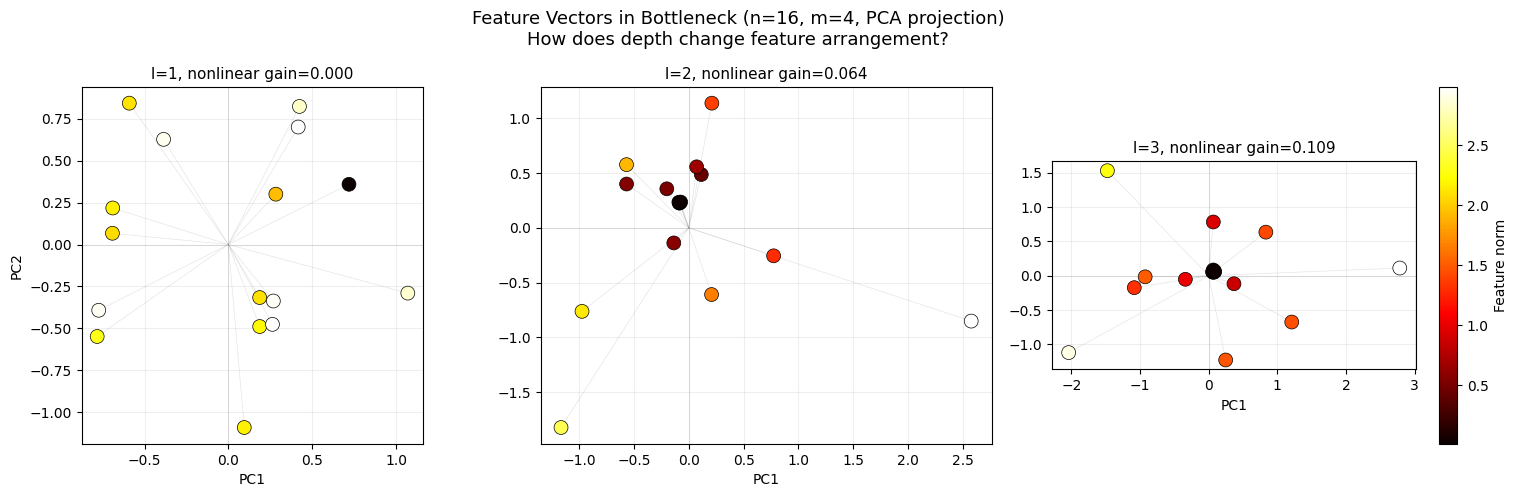

In [12]:
# 2D feature embedding for a high-compression case
# Show how features are arranged in bottleneck space
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

n_viz = 16
m_viz = 4  # high compression forces superposition

for ax_idx, l in enumerate(depths):
    ax = axes[ax_idx]
    
    torch.manual_seed(0)
    model = Autoencoder(n_viz, m_viz, l=l, tied_weights=(l==1)).to(device)
    train_autoencoder(model, n_steps=n_steps, S=S, verbose=False)
    W = get_encoder_weight_matrix(model)
    linearity = measure_encoding_linearity(model, S=S)
    
    # Project feature vectors to 2D via PCA for visualization
    features = W.T.cpu().numpy()  # (n, m)
    center = features.mean(axis=0)
    centered = features - center
    U, s, Vt = np.linalg.svd(centered, full_matrices=False)
    proj_2d = centered @ Vt[:2].T  # (n, 2)
    
    # Color by feature norm (importance proxy)
    norms = np.linalg.norm(features, axis=1)
    scatter = ax.scatter(proj_2d[:, 0], proj_2d[:, 1], 
                        c=norms, cmap='hot', s=100, 
                        edgecolors='black', linewidths=0.5, zorder=5)
    
    # Label features
    for i in range(n_viz):
        ax.annotate(str(i), (proj_2d[i, 0], proj_2d[i, 1]), 
                   fontsize=7, ha='center', va='center', color='white',
                   fontweight='bold')
    
    # Draw lines from origin to each feature
    for i in range(n_viz):
        ax.plot([0, proj_2d[i, 0]], [0, proj_2d[i, 1]], 
               color='gray', alpha=0.2, linewidth=0.5)
    
    ax.axhline(y=0, color='gray', linewidth=0.5, alpha=0.3)
    ax.axvline(x=0, color='gray', linewidth=0.5, alpha=0.3)
    ax.set_title(f'l={l}, nonlinear gain={linearity["nonlinear_gain"]:.3f}', fontsize=11)
    ax.set_xlabel('PC1')
    if ax_idx == 0:
        ax.set_ylabel('PC2')
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.2)

plt.colorbar(scatter, ax=axes[-1], label='Feature norm')
plt.suptitle(f'Feature Vectors in Bottleneck (n={n_viz}, m={m_viz}, PCA projection)\n'
             'How does depth change feature arrangement?',
             fontsize=13)
plt.tight_layout()
plt.show()

## Part 9: Summary and connections

### The neuroscience ↔ ML interpretability bridge

| Neuroscience concept | ML interpretability analog | Our toy model measurement |
|---------------------|---------------------------|---------------------------|
| **RSA / RDMs** (Kriegeskorte 2008) | Feature cosine similarity structure | `compute_rdm()` + structure score vs random |
| **Representational format** (Kriegeskorte & Diedrichsen 2019) | Feature geometry beyond content | RDM entropy, clustering |
| **Manifold capacity** (Chung & Abbott 2021) | Linear separability of feature representations | `capacity` metric via random dichotomies |
| **Manifold dimensionality/radius** | Feature cloud shape | `eff_dim`, `mean_radius` |
| **Population code** | Superposition | Frame operator spectrum |
| **Tuning curve heterogeneity** | Feature norm variation | `norm_cv` |

### The jake_mendel / Lee Sharkey critique, formalized

The superposition hypothesis predicts:
- RDM structure ≈ random packing → **Our test**: entropy ratio ≈ 1
- Feature norms uniform → **Our test**: norm CV ≈ 0  
- Gram spectrum matches random matrix theory → **Our test**: eigenvalue clustering

If any of these fail, geometry carries information beyond superposition.

### Connection to our phase diagram

The (n, m, l) phase diagram from our main experiments maps onto representational geometry:
- **Low compression (m ≈ n)**: Features approximately orthogonal, RDM ≈ identity, minimal geometric structure. Neuroscience analog: overcomplete basis in early sensory cortex.
- **High compression (m << n)**: Heavy superposition forces geometric organization (polytopes, tight frames). Neuroscience analog: compressed population codes in higher cortex.
- **Depth transition**: Deeper encoders may reorganize feature geometry beyond what linear superposition produces, creating "genuinely representational" structure.

### The Ivanov spectral theory connection

The frame operator F = WW^T provides the invariant description of feature geometry that neuroscience's RSA seeks. At capacity saturation (high n/m), spectral localization forces features into tight frames — the same polytopes Elhage found empirically. This is the mathematical bridge: **superposition IS a form of representational geometry**, but it's the minimal/optimal geometry for packing. The jake_mendel claim is that real networks go beyond this minimum.